Un **Autoencoder** es un tipo especial de de arquitectura red neuronal con habilidades generativas: es entrenada para replicar el contenido original de entrada en su salida, obteniéndose en el "centro" de la misma una representación codificada del contenido.

Por ejemplo, dada la imagen de un dígito escrito a mano como los del dataset MNIST, un autocodificador en su primera mitad (encoder) codifica la imagen en una representación latente de menor dimensión, para posteriormente (decoder) decodificarla de nuevo en una imagen lo más fiel posible a la original. En definitiva, aprende a comprimir los datos, buscando durante su entrenamiento el minimizar el error cometido en la reconstrucción.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

En nuestro caso, el dataset con el que vamos a probar a entrenar un autoencoder es el de Fashion MNIST, que contiene imágenes de prendas de vestir en B/N y en baja resolución.

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255. # Normalizamos los valores manualmente a 0-1
x_test = x_test.astype('float32') / 255.

print (x_train.shape)
print (x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


Definiremos un autoencoder muy sencillo con dos capas densas, una será el encoder y la otra el decoder: el encoder comprime las imágenes en un vector latente de 64 dimensiones, y el decoder que reconstruye la imagen original a partir del espacio latente.

In [3]:
class Autoencoder(Model):
  def __init__(self, latent_dim, shape):
    super(Autoencoder, self).__init__() # Inicializamos un objeto AutoEncoder que hereda de la clase Model de Keras
    self.latent_dim = latent_dim # Será de 64
    self.shape = shape # Será de 28x28
    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(latent_dim, activation='relu'), # Encoder de una sola capa oculta, precedida por la capa de entrada 'Flatten'
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(int(tf.math.reduce_prod(shape).numpy()), activation='sigmoid'), # se especifica volver al tamaño original de 784, asegurándose con la activación
      # sigmoidal que los valores queden entre 0 y 1
      layers.Reshape(shape) # vuelve del 1D al 2D (revertir el proceso del Flatten)
    ])

  def call(self, x): # define el flujo de información (forward pass) a través del autoencoder
    encoded = self.encoder(x) # primero la entrada x atraviesa el encoder
    decoded = self.decoder(encoded) # Despues la representación latente viaja a través del decoder
    return decoded


shape = x_test.shape[1:] # height, width (se omite la posición/dimensión 0 que contiene num_images)
latent_dim = 64
autoencoder = Autoencoder(latent_dim, shape)

In [4]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

Entrenamos el modelo usando `x_train` como es habitual. El encoder aprenderá a comprimir el conjunto de datos de 784 dimensiones al espacio latente, y el decoder aprenderá a reconstruir las imágenes originales a partir del espacio latente de 64 dimensiones.

In [5]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0241 - val_loss: 0.0137
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0118 - val_loss: 0.0106
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0101 - val_loss: 0.0098
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0095 - val_loss: 0.0094
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0092 - val_loss: 0.0092
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0091 - val_loss: 0.0091
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0090 - val_loss: 0.0090
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0089 - val_loss: 0.0091
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0088 - val_loss: 0.0089
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0088 - val_loss: 0.0089


Una vez entrenado, le pasamos ejemplos de prueba. Como un autoencoder tiene una doble arquitectura, el flujo se realiza a través de dos etapas diferenciadas:

In [6]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

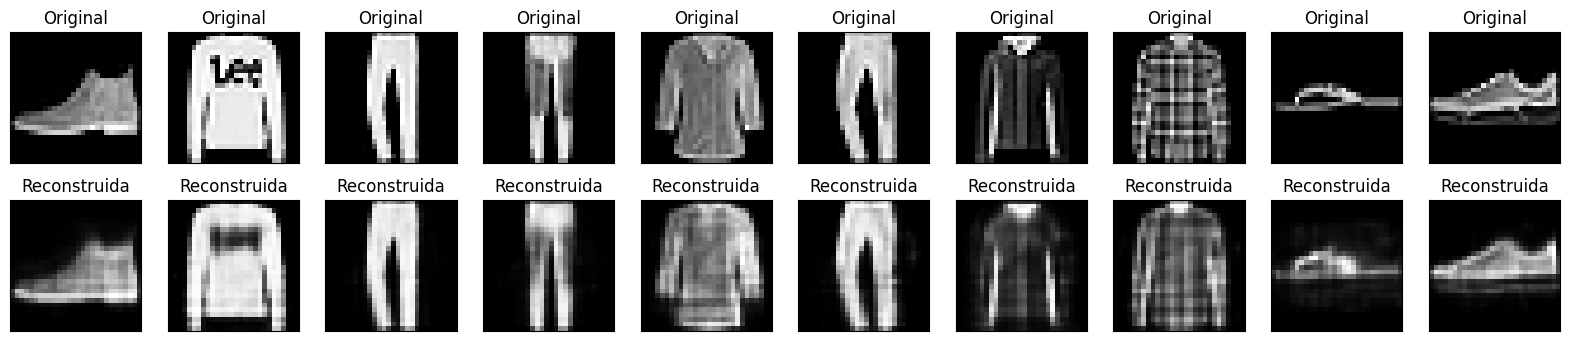

In [7]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # display original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_test[i])
  plt.title("Original")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.title("Reconstruida")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()